In [ ]:
forestgrowthfoundationsbackup


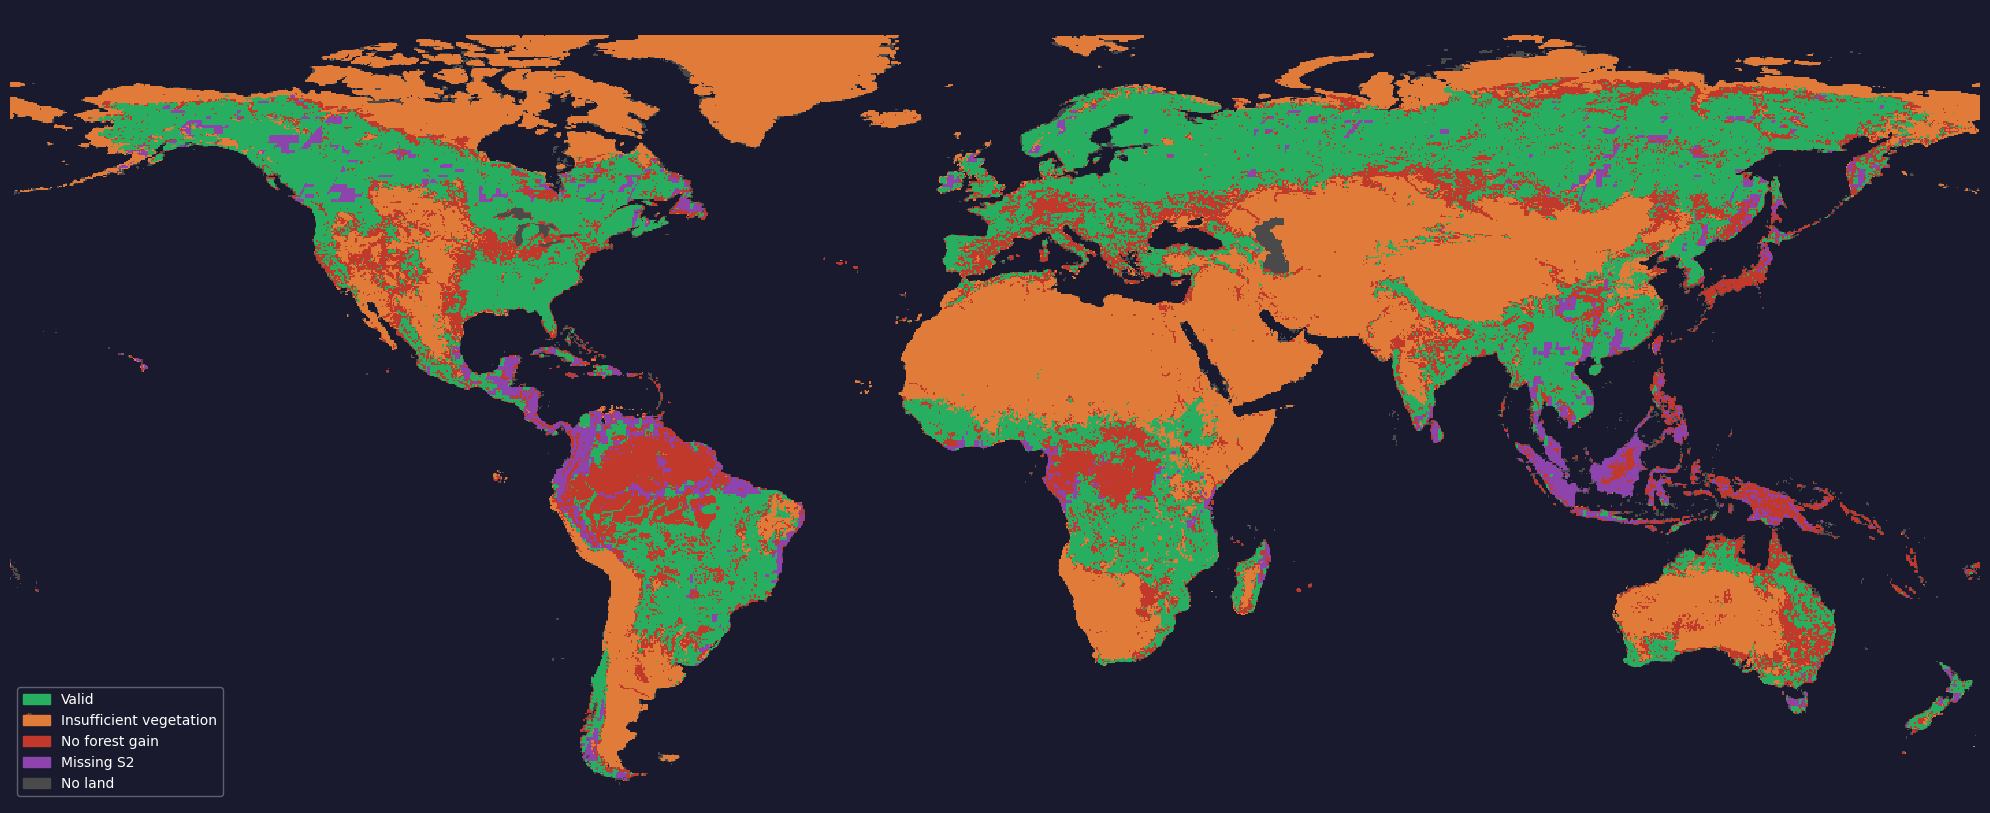

In [5]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

STEP = 0.25

lon_min = -180.0
lat_min = -60.0

lon_bins = int(360 / STEP)
lat_bins = int(145 / STEP)

# 0 = empty
# 1 = no_land
# 2 = insufficient_veg
# 3 = no_forest_gain
# 4 = missing_s2
# 5 = valid

grid = np.zeros((lat_bins, lon_bins), dtype=np.uint8)

REJECTION_CODE = {
    "no_land": 1,
    "insufficient_veg": 2,
    "no_forest_gain": 3,
    "missing_s2": 4,
    "valid": 5,
}


def get_props(a):
    return a.get("properties", a)


def add_to_grid(aois):
    for a in aois:
        p = get_props(a)

        min_lon = p.get("minLon")
        max_lon = p.get("maxLon")
        min_lat = p.get("minLat")
        max_lat = p.get("maxLat")
        reason = p.get("rejection_reason", "")

        if None in (min_lon, max_lon, min_lat, max_lat):
            continue

        code = REJECTION_CODE.get(reason, 0)
        if code == 0:
            continue

        lon = (min_lon + max_lon) / 2
        lat = (min_lat + max_lat) / 2

        x = int((lon - lon_min) / STEP)
        y = int((lat - lat_min) / STEP)

        if 0 <= x < lon_bins and 0 <= y < lat_bins:
            grid[y, x] = code


with open("data/aois/valid_aois.json") as f:
    valid_aois = json.load(f)

with open("data/aois/rejected_aois.json") as f:
    rejected_aois = json.load(f)

add_to_grid(rejected_aois)
add_to_grid(valid_aois)

colors = [
    "#1a1a2e",  # 0 empty
    "#4a4a4a",  # 1 no_land
    "#e07b39",  # 2 insufficient_veg
    "#c0392b",  # 3 no_forest_gain
    "#8e44ad",  # 4 missing_s2
    "#27ae60",  # 5 valid
]

from matplotlib.colors import ListedColormap

cmap = ListedColormap(colors)

plt.figure(figsize=(20, 10), facecolor="#1a1a2e")
ax = plt.gca()
ax.set_facecolor("#1a1a2e")

ax.imshow(
    grid,
    origin="lower",
    interpolation="nearest",
    cmap=cmap,
    vmin=0,
    vmax=5,
)

legend_elements = [
    mpatches.Patch(color="#27ae60", label="Valid"),
    mpatches.Patch(color="#e07b39", label="Insufficient vegetation"),
    mpatches.Patch(color="#c0392b", label="No forest gain"),
    mpatches.Patch(color="#8e44ad", label="Missing S2"),
    mpatches.Patch(color="#4a4a4a", label="No land"),
]

ax.legend(
    handles=legend_elements,
    loc="lower left",
    framealpha=0.3,
    facecolor="#1a1a2e",
    edgecolor="white",
    labelcolor="white",
    fontsize=10,
)

ax.axis("off")
plt.tight_layout()
plt.savefig("data/aois/aoi_map.png", dpi=150, bbox_inches="tight", facecolor="#1a1a2e")
plt.show()

In [19]:
import json
from pathlib import Path

BASE = Path("data/aois")

ALL_AOIS_FILE = BASE / "all_aois.json"
VALID_FILE = BASE / "valid_aois.json"
REJECTED_FILE = BASE / "rejected_aois.json"

CHECKPOINT_FILE = BASE / "aoi_filter_checkpoint.json"

with open(ALL_AOIS_FILE) as f:
    all_aois = json.load(f)

with open(VALID_FILE) as f:
    valid_aois = json.load(f)

with open(REJECTED_FILE) as f:
    rejected_aois = json.load(f)

all_ids = {
    a["properties"]["id"]
    for a in all_aois
}

valid_ids = {
    a["id"]
    for a in valid_aois
}

rejected_ids = {
    a["id"]
    for a in rejected_aois
}

done_ids = valid_ids | rejected_ids

missing_ids = all_ids - done_ids

checkpoint = {
    "valid": valid_aois,
    "rejected": rejected_aois,
}

with open(CHECKPOINT_FILE, "w") as f:
    json.dump(checkpoint, f)

print(f"All AOIs       : {len(all_ids):,}")
print(f"Valid AOIs     : {len(valid_ids):,}")
print(f"Rejected AOIs  : {len(rejected_ids):,}")
print(f"Done AOIs      : {len(done_ids):,}")
print(f"Missing AOIs   : {len(missing_ids):,}")

dupes = len(valid_ids) + len(rejected_ids) - len(done_ids)

print(f"Duplicate IDs  : {dupes:,}")

if dupes > 0:
    print("WARNING: duplicate AOI IDs detected")

print(f"\nCheckpoint written to:")
print(CHECKPOINT_FILE)

All AOIs       : 261,206
Valid AOIs     : 92,583
Rejected AOIs  : 168,623
Done AOIs      : 261,206
Missing AOIs   : 0
Duplicate IDs  : 0

Checkpoint written to:
data/aois/aoi_filter_checkpoint.json


In [46]:
import json
import statistics
from collections import Counter
from pathlib import Path


AOI_DIR = Path("data/aois")
VALID_PATH    = AOI_DIR / "valid_aois_enriched.json"
REJECTED_PATH = AOI_DIR / "rejected_aois_enriched.json"

def load(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path.resolve()}")
    with open(path) as f:
        return json.load(f)

def num_stats(values, label, unit=""):
    vals = [v for v in values if v is not None]
    if not vals:
        return {}
    vals_sorted = sorted(vals)
    n = len(vals)
    mean = sum(vals) / n
    med  = statistics.median(vals)
    sd   = statistics.stdev(vals) if n > 1 else 0
    return {
        "label": label,
        "unit":  unit,
        "n":     n,
        "min":   vals_sorted[0],
        "p25":   vals_sorted[int(n * 0.25)],
        "mean":  mean,
        "median":med,
        "p75":   vals_sorted[int(n * 0.75)],
        "max":   vals_sorted[-1],
        "stdev": sd,
    }

def fmt(v, decimals=4):
    if isinstance(v, float):
        return f"{v:>{12}.{decimals}f}"
    if isinstance(v, int):
        return f"{v:>12,}"
    return f"{str(v):>12}"

def print_stats(s):
    if not s:
        return
    unit_str = f" ({s['unit']})" if s['unit'] else ""
    print(f"\n  {s['label']}{unit_str}  [n={s['n']:,}]")
    print(f"    {'Min':<10} {fmt(s['min'])}")
    print(f"    {'P25':<10} {fmt(s['p25'])}")
    print(f"    {'Mean':<10} {fmt(s['mean'])}")
    print(f"    {'Median':<10} {fmt(s['median'])}")
    print(f"    {'P75':<10} {fmt(s['p75'])}")
    print(f"    {'Max':<10} {fmt(s['max'])}")
    print(f"    {'Std Dev':<10} {fmt(s['stdev'])}")

def section(title):
    width = 68
    print()
    print("=" * width)
    print(f"  {title}")
    print("=" * width)

def subsection(title):
    print(f"\n── {title} " + "─" * (60 - len(title)))

def pct(part, total):
    return 100 * part / total if total else 0

print("Loading data …", flush=True)
valid    = load(VALID_PATH)
rejected = load(REJECTED_PATH)
all_aois = valid + rejected

n_valid    = len(valid)
n_rejected = len(rejected)
n_total    = len(all_aois)

section("1. DATASET OVERVIEW")
print(f"\n  Total AOIs          : {n_total:>10,}")
print(f"  Valid               : {n_valid:>10,}  ({pct(n_valid,  n_total):.1f} %)")
print(f"  Rejected            : {n_rejected:>10,}  ({pct(n_rejected, n_total):.1f} %)")

section("2. REJECTION REASON BREAKDOWN")
reasons = Counter(r["rejection_reason"] for r in rejected)
print(f"\n  {'Reason':<25} {'Count':>10}  {'% of Rejected':>14}  {'% of Total':>10}")
print(f"  {'-'*25} {'-'*10}  {'-'*14}  {'-'*10}")
for reason, cnt in reasons.most_common():
    print(f"  {reason:<25} {cnt:>10,}  {pct(cnt, n_rejected):>13.1f}%  {pct(cnt, n_total):>9.1f}%")

section("3. GEOGRAPHIC COVERAGE")
for label, dataset in [("Valid AOIs", valid), ("Rejected AOIs", rejected), ("All AOIs", all_aois)]:
    lats = [r["centroid_lat"] for r in dataset]
    lons = [r["centroid_lon"] for r in dataset]
    subsection(label)
    print(f"    Latitude  range : {min(lats):>9.3f} → {max(lats):.3f}")
    print(f"    Longitude range : {min(lons):>9.3f} → {max(lons):.3f}")

section("4. REGIONAL DISTRIBUTION")
for label, dataset in [("Valid", valid), ("Rejected", rejected)]:
    subsection(label)
    regions = Counter(r.get("region", "Unknown") for r in dataset)
    n = len(dataset)
    print(f"  {'Region':<30} {'Count':>8}  {'%':>6}")
    print(f"  {'-'*30} {'-'*8}  {'-'*6}")
    for region, cnt in regions.most_common():
        print(f"  {region:<30} {cnt:>8,}  {pct(cnt,n):>5.1f}%")

section("5. BIOME DISTRIBUTION")
for label, dataset in [("Valid", valid), ("Rejected", rejected)]:
    subsection(label)
    biomes = Counter(r.get("biome_name", "Unknown") for r in dataset)
    n = len(dataset)
    print(f"  {'Biome':<45} {'Count':>8}  {'%':>6}")
    print(f"  {'-'*45} {'-'*8}  {'-'*6}")
    for biome, cnt in biomes.most_common():
        print(f"  {biome:<45} {cnt:>8,}  {pct(cnt,n):>5.1f}%")

section("6. NUMERIC STATISTICS — VALID AOIs")
numeric_fields = [
    ("aoi_area_km2",         "AOI Area",             "km²"),
    ("land_frac",            "Land Fraction",        "0–1"),
    ("veg_fraction",         "Vegetation Fraction",  "0–1"),
    ("forest_gain_area_km2", "Forest Gain Area",     "km²"),
    ("forest_gain_frac",     "Forest Gain Fraction", "0–1"),
    ("forest_gain_pixels",   "Forest Gain Pixels",   "px"),
]
for field, label, unit in numeric_fields:
    vals = [r[field] for r in valid if field in r]
    print_stats(num_stats(vals, label, unit))

section("7. NUMERIC STATISTICS — REJECTED AOIs")
for field, label, unit in numeric_fields:
    vals = [r[field] for r in rejected if field in r]
    print_stats(num_stats(vals, label, unit))

section("8. BOOLEAN FLAG SUMMARY")
flags = ["has_land", "has_s2", "has_veg", "has_gain"]
print(f"\n  {'Flag':<15} {'Valid (n / %)':<20} {'Rejected (n / %)':<20}")
print(f"  {'-'*15} {'-'*20} {'-'*20}")
for flag in flags:
    v_n = sum(1 for r in valid    if r.get(flag, 0) == 1)
    r_n = sum(1 for r in rejected if r.get(flag, 0) == 1)
    print(f"  {flag:<15} {f'{v_n:,} / {pct(v_n, n_valid):.1f}%':<20} {f'{r_n:,} / {pct(r_n, n_rejected):.1f}%':<20}")

section("9. FOREST GAIN — VALID vs REJECTED COMPARISON")
for label, dataset in [("Valid", valid), ("Rejected", rejected)]:
    areas = [r["forest_gain_area_km2"] for r in dataset if "forest_gain_area_km2" in r]
    total_gain = sum(areas)
    has_gain   = sum(1 for a in areas if a > 0)
    subsection(label)
    print(f"    Total forest gain area : {total_gain:>12,.2f} km²")
    print(f"    AOIs with any gain     : {has_gain:>12,}  ({pct(has_gain, len(areas)):.1f}%)")
    print(f"    Mean gain per AOI      : {total_gain/len(areas):>12.4f} km²")

print()
print("=" * 68)
print("  Done.")
print("=" * 68)
print()

Loading data …

  1. DATASET OVERVIEW

  Total AOIs          :    261,206
  Valid               :     92,583  (35.4 %)
  Rejected            :    168,623  (64.6 %)

  2. REJECTION REASON BREAKDOWN

  Reason                         Count   % of Rejected  % of Total
  ------------------------- ----------  --------------  ----------
  insufficient_veg             103,957           61.7%       39.8%
  no_forest_gain                45,143           26.8%       17.3%
  missing_s2                    11,868            7.0%        4.5%
  no_land                        7,655            4.5%        2.9%

  3. GEOGRAPHIC COVERAGE

── Valid AOIs ──────────────────────────────────────────────────
    Latitude  range :   -55.375 → 72.375
    Longitude range :  -165.125 → 179.125

── Rejected AOIs ───────────────────────────────────────────────
    Latitude  range :   -56.625 → 80.125
    Longitude range :  -179.875 → 179.875

── All AOIs ────────────────────────────────────────────────────
    Latitu

In [52]:
import json
import random
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

AOI_DIR       = Path("data/aois")
VALID_PATH    = AOI_DIR / "valid_aois_enriched.json"
REJECTED_PATH = AOI_DIR / "rejected_aois_enriched.json"
OUT_DIR       = Path("plots")
SCATTER_N     = 3000
RANDOM_SEED   = 42

OUT_DIR.mkdir(exist_ok=True)
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

plt.rcParams.update({
    "figure.facecolor": "#0d1117",
    "axes.facecolor":   "#161b22",
    "axes.edgecolor":   "#30363d",
    "axes.labelcolor":  "#c9d1d9",
    "xtick.color":      "#8b949e",
    "ytick.color":      "#8b949e",
    "text.color":       "#e6edf3",
    "grid.color":       "#21262d",
    "grid.linestyle":   "--",
    "grid.alpha":       0.6,
    "legend.facecolor": "#1c2128",
    "legend.edgecolor": "#30363d",
    "font.family":      "monospace",
    "font.size":        10,
})

# Perceptually distinct, colourblind-safe (Wong 2011 + tweaks)
COLORS = {
    "valid":            "#2ecc71",   # vivid green
    "no_land":          "#3498db",   # blue
    "insufficient_veg": "#e67e22",   # orange
    "no_forest_gain":   "#e74c3c",   # red
    "missing_s2":       "#9b59b6",   # purple
}
REASON_LABELS = {
    "valid":            "Valid",
    "no_land":          "No Land",
    "insufficient_veg": "Insuff. Veg",
    "no_forest_gain":   "No Forest Gain",
    "missing_s2":       "Missing S2",
}
REASONS = ["valid", "no_land", "insufficient_veg", "no_forest_gain", "missing_s2"]

def threshold_vline(ax, x, label, color="#facc15", alpha=0.12, lw=1.8):
    ax.axvline(x, color=color, lw=lw, zorder=4)
    ax.axvspan(ax.get_xlim()[0], x, color=color, alpha=alpha, zorder=0)
    ymax = ax.get_ylim()[1]
    ax.text(x + (ax.get_xlim()[1] - ax.get_xlim()[0]) * 0.01, ymax * 0.96,
            label, color=color, fontsize=8, fontweight="bold", va="top", zorder=5)

def threshold_hline(ax, y, label, color="#facc15", alpha=0.12, lw=1.8):
    ax.axhline(y, color=color, lw=lw, zorder=4)
    ax.axhspan(ax.get_ylim()[0], y, color=color, alpha=alpha, zorder=0)
    xmax = ax.get_xlim()[1]
    ax.text(xmax * 0.01, y * 1.08, label, color=color,
            fontsize=8, fontweight="bold", va="bottom", zorder=5)

print("Loading data…")
with open(VALID_PATH) as f:
    valid = json.load(f)
with open(REJECTED_PATH) as f:
    rejected = json.load(f)

all_aois = valid + rejected
n_valid, n_rejected, n_total = len(valid), len(rejected), len(all_aois)
print(f"  {n_valid:,} valid  |  {n_rejected:,} rejected  |  {n_total:,} total")

v_sample = random.sample(valid,    min(SCATTER_N, n_valid))
r_sample = random.sample(rejected, min(SCATTER_N, n_rejected))

def savefig(name):
    p = OUT_DIR / name
    plt.savefig(p, dpi=150, bbox_inches="tight", facecolor=plt.gcf().get_facecolor())
    plt.close()
    print(f"  → {p}")

skip = {"Unknown", "N/A"}

def short_biome(b):
    return (b.replace("Tropical & Subtropical ", "T&S ")
             .replace("Temperate ", "Temp. ")
             .replace(", Savannas & Shrublands", "/Sav")
             .replace("Grasslands", "Grass")
             .replace("Forests/Taiga", "Forests")
             .replace(" & Mixed Forests", "")
             .replace("Woodlands & Scrub", "Scrub")
             .replace("Deserts & Xeric Shrublands", "Deserts/Xeric")
             .replace("Flooded Grasslands & Savannas", "Flooded Grass")
             .replace("Montane Grasslands & Shrublands", "Montane Grass")
             .replace(" Forests", ""))

print("\n[1/11] Density heatmaps…")

LAT_BINS, LON_BINS = 580, 1440  # 0.25° cells

def density_grid(records):
    grid = np.zeros((LAT_BINS, LON_BINS))
    for r in records:
        li = int(np.clip((r["centroid_lat"] + 60) / 0.25, 0, LAT_BINS - 1))
        lo = int(np.clip((r["centroid_lon"] + 180) / 0.25, 0, LON_BINS - 1))
        grid[li, lo] += 1
    return grid

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle("AOI Spatial Density  (0.25° cells)", color="#e6edf3", fontsize=13, y=1.01)

specs = [
    (valid,    "Valid AOIs",    ["#0d2a1a", "#2ecc71"]),
    (rejected, "Rejected AOIs", ["#2a0d0d", "#e74c3c"]),
]
for ax, (records, title, clrs) in zip(axes, specs):
    grid = density_grid(records)
    cmap = LinearSegmentedColormap.from_list("", clrs)
    im = ax.imshow(
        np.flipud(grid ** 0.4),
        extent=[-180, 180, -60, 85],
        aspect="auto", cmap=cmap, interpolation="nearest",
    )
    plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label="Count (γ=0.4)")
    ax.set_title(title, color="#e6edf3", fontsize=11)
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    ax.axhline(0, color="#30363d", lw=0.4)
    ax.axvline(0, color="#30363d", lw=0.4)
    ax.grid(True, lw=0.3)

plt.tight_layout()
savefig("01_density_heatmaps.png")

print("[2/11] Stacked bar by region…")

region_counts = defaultdict(Counter)
for r in all_aois:
    region_counts[r.get("region", "Unknown")][r.get("rejection_reason", "valid")] += 1

regions = [k for k in sorted(region_counts, key=lambda k: -sum(region_counts[k].values()))
           if k not in skip]

fig, ax = plt.subplots(figsize=(11, 5))
fig.suptitle("Rejection Composition by Biogeographic Realm", color="#e6edf3", fontsize=12)
bottoms = np.zeros(len(regions))
for reason in REASONS:
    vals = np.array([(region_counts[r].get(reason, 0) / sum(region_counts[r].values()))
                     for r in regions])
    ax.bar(regions, vals, bottom=bottoms, color=COLORS[reason],
           label=REASON_LABELS[reason], width=0.6)
    bottoms += vals

ax.set_ylabel("Proportion"); ax.set_ylim(0, 1)
ax.set_xticklabels(regions, rotation=25, ha="right")
ax.legend(loc="upper right", fontsize=9)
ax.yaxis.grid(True); ax.set_axisbelow(True)
plt.tight_layout()
savefig("02_stacked_bar_region.png")

print("[3/11] Stacked bar by biome…")

biome_counts = defaultdict(Counter)
for r in all_aois:
    biome_counts[r.get("biome_name", "Unknown")][r.get("rejection_reason", "valid")] += 1

biomes_all = [k for k in sorted(biome_counts, key=lambda k: -sum(biome_counts[k].values()))
              if k not in skip]

fig, ax = plt.subplots(figsize=(16, 5))
fig.suptitle("Rejection Composition by Biome", color="#e6edf3", fontsize=12)
bottoms = np.zeros(len(biomes_all))
for reason in REASONS:
    vals = np.array([(biome_counts[b].get(reason, 0) / sum(biome_counts[b].values()))
                     for b in biomes_all])
    ax.bar([short_biome(b) for b in biomes_all], vals, bottom=bottoms,
           color=COLORS[reason], label=REASON_LABELS[reason], width=0.6)
    bottoms += vals

ax.set_ylabel("Proportion"); ax.set_ylim(0, 1)
ax.set_xticklabels([short_biome(b) for b in biomes_all], rotation=35, ha="right", fontsize=8)
ax.legend(loc="upper right", fontsize=9)
ax.yaxis.grid(True); ax.set_axisbelow(True)
plt.tight_layout()
savefig("03_stacked_bar_biome.png")

print("[4/11] Filter funnel…")

funnel = {
    "All AOIs":        n_total,
    "Has Land":        n_total - sum(1 for r in rejected if r.get("rejection_reason") == "no_land"),
    "Has Vegetation":  n_total - sum(1 for r in rejected if r.get("rejection_reason") in {"no_land", "insufficient_veg"}),
    "Has Forest Gain": n_total - sum(1 for r in rejected if r.get("rejection_reason") in {"no_land", "insufficient_veg", "no_forest_gain"}),
    "Has S2 (Valid)":  n_valid,
}
labels = list(funnel.keys())
values = list(funnel.values())

fig, ax = plt.subplots(figsize=(8, 5))
fig.suptitle("AOI Filter Stage Funnel", color="#e6edf3", fontsize=12)

cmap_f = LinearSegmentedColormap.from_list("", ["#3498db", "#2ecc71"])
colors_f = [cmap_f(i / (len(labels) - 1)) for i in range(len(labels))]

max_val = max(values)

# Reverse for top-to-bottom funnel
labels_r = labels[::-1]
values_r = values[::-1]
colors_r = colors_f[::-1]

# Center each bar
lefts = [(max_val - v) / 2 for v in values_r]

bars = ax.barh(
    labels_r,
    values_r,
    left=lefts,
    color=colors_r,
    height=0.7
)

# Put count + percentage inside each bar
for bar, v in zip(bars, values_r):
    pct = 100 * v / n_total

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_y() + bar.get_height() / 2,
        f"{v:,}\n({pct:.1f}%)",
        ha="center",
        va="center",
        color="white",
        fontsize=9,
        fontweight="bold"
    )

ax.set_xlim(0, max_val)
ax.set_xlabel("AOI Count")

# Hide x-axis if you want a cleaner funnel look
ax.set_xticks([])

# Remove unnecessary spines
for spine in ["top", "right", "bottom"]:
    ax.spines[spine].set_visible(False)

ax.grid(False)

plt.tight_layout()
savefig("04_filter_funnel.png")

print("[5/11] Pairplot…")

PAIR_FIELDS = ["veg_fraction", "forest_gain_frac", "land_frac", "aoi_area_km2"]
PAIR_LABELS = ["Veg Fraction", "Gain Fraction", "Land Fraction", "AOI Area km²"]
N_PAIR = 800

vp = random.sample(v_sample, min(N_PAIR, len(v_sample)))
rp = random.sample(r_sample, min(N_PAIR, len(r_sample)))

def extract(records, fields):
    return np.array([[r.get(f, 0) for f in fields] for r in records])

Vmat = extract(vp, PAIR_FIELDS)
Rmat = extract(rp, PAIR_FIELDS)

n = len(PAIR_FIELDS)
fig, axes = plt.subplots(n, n, figsize=(12, 10))
fig.suptitle("Pairplot — Valid (green) vs Rejected (red)", color="#e6edf3", fontsize=12, y=1.01)

for i in range(n):
    for j in range(n):
        ax = axes[i][j]
        if i == j:
            ax.hist(Vmat[:, i], bins=30, color=COLORS["valid"], alpha=0.55, density=True)
            ax.hist(Rmat[:, i], bins=30, color=COLORS["no_forest_gain"], alpha=0.55, density=True)
        else:
            ax.scatter(Rmat[:, j], Rmat[:, i], c=COLORS["no_forest_gain"],
                       s=5, alpha=0.3, linewidths=0, rasterized=True)
            ax.scatter(Vmat[:, j], Vmat[:, i], c=COLORS["valid"],
                       s=5, alpha=0.4, linewidths=0, rasterized=True)

        if i == n - 1: ax.set_xlabel(PAIR_LABELS[j], fontsize=8)
        else:          ax.set_xticklabels([])
        if j == 0:     ax.set_ylabel(PAIR_LABELS[i], fontsize=8)
        else:          ax.set_yticklabels([])
        ax.tick_params(labelsize=7)

plt.tight_layout()
savefig("05_pairplot.png")

print("[6/11] Correlation heatmap…")

NUM_FIELDS  = ["aoi_area_km2", "land_frac", "veg_fraction",
               "forest_gain_frac", "forest_gain_area_km2"]
SHORT_NAMES = ["aoi_area", "land_frac", "veg_frac", "gain_frac", "gain_area"]

corr_data = np.array([[r.get(f, 0) for f in NUM_FIELDS] for r in valid], dtype=float)
C = np.corrcoef(corr_data.T)

# p-value approximation for significance stars (t-distribution)
from scipy import stats as _stats
n_obs = len(valid)
def pval(r, n):
    if abs(r) >= 1: return 0.0
    t = r * np.sqrt((n - 2) / (1 - r**2))
    return 2 * _stats.t.sf(abs(t), df=n - 2)

n_f = len(NUM_FIELDS)
CELL = 90   # px per cell → controls figure size
fig_px = CELL * n_f
fig, ax = plt.subplots(figsize=(fig_px / 72 + 2, fig_px / 72 + 1.5))
fig.suptitle("Correlation Matrix — Valid AOIs", color="#e6edf3", fontsize=13)

# Diverging blue→dark→green — clearly asymmetric around zero
cmap_corr = LinearSegmentedColormap.from_list("corr",
    ["#e74c3c", "#8e1c14", "#161b22", "#1a4d2a", "#2ecc71"])
im = ax.imshow(C, cmap=cmap_corr, vmin=-1, vmax=1, aspect="equal")
cbar = plt.colorbar(im, ax=ax, fraction=0.04, pad=0.03)
cbar.set_label("Pearson r", color="#c9d1d9")
cbar.ax.yaxis.set_tick_params(color="#8b949e")

for i in range(n_f):
    for j in range(n_f):
        r = C[i, j]
        p = pval(r, n_obs)
        star = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else ""))
        # White text on dark cells, dark on bright cells
        txt_color = "#ffffff" if abs(r) > 0.35 else "#8b949e"
        ax.text(j, i, f"{r:.2f}", ha="center", va="center",
                fontsize=10, color=txt_color, fontweight="bold")
        if star and i != j:
            ax.text(j + 0.35, i - 0.32, star, ha="right", va="top",
                    fontsize=7, color=txt_color)

ax.set_xticks(range(n_f)); ax.set_yticks(range(n_f))
ax.set_xticklabels(SHORT_NAMES, rotation=35, ha="right", fontsize=10)
ax.set_yticklabels(SHORT_NAMES, fontsize=10)

# Gridlines between cells
for x in np.arange(-0.5, n_f, 1):
    ax.axhline(x, color="#0d1117", lw=1.5)
    ax.axvline(x, color="#0d1117", lw=1.5)

ax.text(0, -1.2, "* p<0.05  ** p<0.01  *** p<0.001",
        fontsize=8, color="#8b949e", transform=ax.transData)

plt.tight_layout()
savefig("06_corr_matrix.png")


print("[7/11] Biome x region heatmap…")

REGIONS_ORDERED = ["Palearctic", "Nearctic", "Neotropic", "Afrotropic",
                   "Indomalayan", "Australasia", "Oceania"]

biome_region = defaultdict(Counter)
for r in valid:
    b  = r.get("biome_name", "Unknown")
    rg = r.get("region", "Unknown")
    if b not in skip and rg in REGIONS_ORDERED:
        biome_region[b][rg] += 1

biomes_hr = sorted(biome_region, key=lambda b: -sum(biome_region[b].values()))
matrix = np.array([[biome_region[b].get(rg, 0) for rg in REGIONS_ORDERED]
                   for b in biomes_hr], dtype=float)

fig, ax = plt.subplots(figsize=(12, 7))
fig.suptitle("Valid AOI Count — Biome × Region", color="#e6edf3", fontsize=12)

cmap_hr = LinearSegmentedColormap.from_list("", ["#161b22", "#3498db"])
im = ax.imshow(matrix ** 0.5, cmap=cmap_hr, aspect="auto")
plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label="Count (γ=0.5)")

thresh = matrix.max() ** 0.5 * 0.5
for i, b in enumerate(biomes_hr):
    for j, rg in enumerate(REGIONS_ORDERED):
        v = int(matrix[i, j])
        if v > 0:
            tc = "#0d1117" if matrix[i, j] ** 0.5 > thresh else "#8b949e"
            ax.text(j, i, f"{v:,}", ha="center", va="center", fontsize=8, color=tc)

ax.set_xticks(range(len(REGIONS_ORDERED)))
ax.set_xticklabels(REGIONS_ORDERED, rotation=25, ha="right")
ax.set_yticks(range(len(biomes_hr)))
ax.set_yticklabels([short_biome(b) for b in biomes_hr], fontsize=9)
plt.tight_layout()
savefig("07_biome_region_heatmap.png")

print("[8/11] Cumulative forest gain by biome…")

biome_gain_total = Counter()
for r in valid:
    b = r.get("biome_name", "Unknown")
    if b not in skip:
        biome_gain_total[b] += r.get("forest_gain_area_km2", 0)

sorted_bg = sorted(biome_gain_total.items(), key=lambda x: -x[1])
bg_labels = [short_biome(b) for b, _ in sorted_bg]
bg_vals   = [v for _, v in sorted_bg]
total_g   = sum(bg_vals)
bg_cum    = np.cumsum(bg_vals) / total_g * 100

fig, ax1 = plt.subplots(figsize=(14, 5))
fig.suptitle("Cumulative Forest Gain by Biome — Valid AOIs", color="#e6edf3", fontsize=12)

cmap_bg = LinearSegmentedColormap.from_list("", ["#2ecc71", "#0d2a1a"])
bar_colors = [cmap_bg(i / max(len(bg_labels) - 1, 1)) for i in range(len(bg_labels))]
ax1.bar(range(len(bg_labels)), bg_vals, color=bar_colors, width=0.65)
ax1.set_ylabel("Total Gain Area (km²)")
ax1.set_xticks(range(len(bg_labels)))
ax1.set_xticklabels(bg_labels, rotation=35, ha="right", fontsize=8)
ax1.yaxis.grid(True); ax1.set_axisbelow(True)

ax2 = ax1.twinx()
ax2.plot(range(len(bg_labels)), bg_cum, color="#e67e22", lw=2,
         marker="o", ms=5, label="Cumulative %")
ax2.axhline(80, color="#9b59b6", lw=1.8, ls="--", label="80% threshold")
ax2.set_ylabel("Cumulative %", color="#e67e22")
ax2.tick_params(axis="y", colors="#e67e22")
ax2.set_ylim(0, 105)
ax2.legend(loc="center right", fontsize=9)
plt.tight_layout()
savefig("8_cumulative_gain_biome.png")


print("[9/11] Boxplot gain by biome…")

biome_gain_vals = defaultdict(list)
for r in valid:
    b = r.get("biome_name", "Unknown")
    if b not in skip:
        biome_gain_vals[b].append(r["forest_gain_frac"])

biomes_bp = sorted(biome_gain_vals, key=lambda b: -np.median(biome_gain_vals[b]))
bp_data   = [biome_gain_vals[b] for b in biomes_bp]

fig, ax = plt.subplots(figsize=(16, 6))
fig.suptitle("Forest Gain Fraction by Biome — Boxplot (valid AOIs)", color="#e6edf3", fontsize=12)

ax.boxplot(bp_data, positions=range(len(biomes_bp)),
           patch_artist=True, showfliers=False,
           medianprops=dict(color="#2ecc71", linewidth=2.5),
           boxprops=dict(facecolor="#1c2128", edgecolor="#3498db", linewidth=1.5),
           whiskerprops=dict(color="#8b949e", linewidth=1.2),
           capprops=dict(color="#8b949e", linewidth=1.2),
           widths=0.55)

means_bp = [np.mean(d) for d in bp_data]
ax.scatter(range(len(biomes_bp)), means_bp, color="#e67e22",
           zorder=5, s=40, label="Mean", marker="D")

ax.set_ylim(bottom=0)
ax.grid(True, axis="y"); ax.set_axisbelow(True)
threshold_hline(ax, 0.001, "min gain threshold", color="#facc15")

ax.set_xticks(range(len(biomes_bp)))
ax.set_xticklabels([short_biome(b) for b in biomes_bp], rotation=35, ha="right", fontsize=8)
ax.set_ylabel("Forest Gain Fraction")
ax.legend(fontsize=9)
plt.tight_layout()
savefig("9_boxplot_gain_biome.png")

print("\n[10/11] Biome contribution plots…")
print("\n[11/11] Region contribution plots…")

from scipy import stats as _stats

def contribution_figure(groupby_field, title_suffix, filename, label_fn=None):
    if label_fn is None:
        label_fn = lambda x: x

    valid_count = Counter()
    rejected_count = Counter()

    valid_gain = Counter()
    rejected_gain = Counter()

    for r in valid:
        g = r.get(groupby_field, "Unknown")
        if g in skip:
            continue

        valid_count[g] += 1
        valid_gain[g] += r.get("forest_gain_area_km2", 0)

    for r in rejected:
        g = r.get(groupby_field, "Unknown")
        if g in skip:
            continue

        rejected_count[g] += 1
        rejected_gain[g] += r.get("forest_gain_area_km2", 0)

    all_groups = sorted(
        set(valid_count) | set(rejected_count),
        key=lambda g: -(valid_count[g] + rejected_count[g])
    )

    short_labels = [label_fn(g) for g in all_groups]

    v_vals = np.array([valid_count[g] for g in all_groups])
    r_vals = np.array([rejected_count[g] for g in all_groups])

    vg_vals = np.array([valid_gain[g] for g in all_groups])
    rg_vals = np.array([rejected_gain[g] for g in all_groups])

    total_gain = vg_vals + rg_vals

    total = v_vals + r_vals
    rej_rate = np.where(total > 0, r_vals / total * 100, 0)

    x = np.arange(len(all_groups))

    fig, axes = plt.subplots(2, 2, figsize=(17, 10))
    fig.suptitle(
        f"AOI Contribution by {title_suffix}",
        color="#e6edf3",
        fontsize=13
    )

    ax = axes[0, 0]

    ax.bar(
        x,
        v_vals,
        color=COLORS["valid"],
        label="Valid",
        width=0.65,
    )

    ax.bar(
        x,
        r_vals,
        bottom=v_vals,
        color=COLORS["no_forest_gain"],
        label="Rejected",
        width=0.65,
        alpha=0.8,
    )

    ax.set_title("AOI Count — Valid vs Rejected", color="#e6edf3")
    ax.set_ylabel("Count")
    ax.set_xticks(x)
    ax.set_xticklabels(short_labels, rotation=35, ha="right", fontsize=8)
    ax.legend(fontsize=9)
    ax.yaxis.grid(True)
    ax.set_axisbelow(True)

    ax = axes[0, 1]

    bars = ax.bar(
        x,
        rej_rate,
        color=[plt.cm.RdYlGn_r(v / 100) for v in rej_rate],
        width=0.65,
    )

    ax.set_title("Rejection Rate (%)", color="#e6edf3")
    ax.set_ylabel("% Rejected")
    ax.set_ylim(0, 105)

    ax.set_xticks(x)
    ax.set_xticklabels(short_labels, rotation=35, ha="right", fontsize=8)

    for bar, val in zip(bars, rej_rate):
        if val > 5:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                val + 1,
                f"{val:.0f}%",
                ha="center",
                fontsize=7,
                color="#e6edf3",
            )

    ax.yaxis.grid(True)
    ax.set_axisbelow(True)

    ax = axes[1, 0]

    ax.bar(
        x,
        vg_vals,
        color="#2ecc71",
        label="Gain in Valid AOIs",
        width=0.65,
    )

    ax.bar(
        x,
        rg_vals,
        bottom=vg_vals,
        color="#e74c3c",
        alpha=0.85,
        label="Gain in Rejected AOIs",
        width=0.65,
    )

    ax.set_title(
        "Total Forest Gain Area (Valid + Rejected)",
        color="#e6edf3",
    )

    ax.set_ylabel("Gain Area (km²)")
    ax.set_xticks(x)
    ax.set_xticklabels(short_labels, rotation=35, ha="right", fontsize=8)
    ax.legend(fontsize=8)

    ax.yaxis.grid(True)
    ax.set_axisbelow(True)

    total_valid_gain = vg_vals.sum()
    total_rejected_gain = rg_vals.sum()
    total_gain_all = total_valid_gain + total_rejected_gain

    pct_retained = (
        100 * total_valid_gain / total_gain_all
        if total_gain_all > 0 else 0
    )

    summary = (
        f"Valid gain: {total_valid_gain:,.0f} km²\n"
        f"Rejected gain: {total_rejected_gain:,.0f} km²\n"
        f"Retained: {pct_retained:.1f}%"
    )

    ax.text(
        0.98,
        0.98,
        summary,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=8,
        bbox=dict(
            facecolor="#161b22",
            edgecolor="#30363d",
            alpha=0.9,
            boxstyle="round,pad=0.4",
        ),
    )

    ax = axes[1, 1]

    gain_retention = np.where(
        total_gain > 0,
        vg_vals / total_gain * 100,
        0,
    )

    bars = ax.bar(
        x,
        gain_retention,
        color=[plt.cm.viridis(v / 100) for v in gain_retention],
        width=0.65,
    )

    ax.set_title(
        "Forest Gain Retained After Filtering (%)",
        color="#e6edf3",
    )

    ax.set_ylabel("% of Gain in Valid AOIs")
    ax.set_ylim(0, 105)

    ax.set_xticks(x)
    ax.set_xticklabels(short_labels, rotation=35, ha="right", fontsize=8)

    for bar, val in zip(bars, gain_retention):
        if val > 5:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                val + 1,
                f"{val:.0f}%",
                ha="center",
                fontsize=7,
                color="#e6edf3",
            )

    ax.yaxis.grid(True)
    ax.set_axisbelow(True)

    for ax in axes.flat:
        ax.tick_params(colors="#8b949e")

    plt.tight_layout()
    savefig(filename)


contribution_figure(
    "biome_name",
    "Biome",
    "10_biome_contribution.png",
    short_biome,
)

contribution_figure(
    "region",
    "Region",
    "11_region_contribution.png",
)

print(f"\nDone — plots saved to ./{OUT_DIR}/")

Loading data…
  92,583 valid  |  168,623 rejected  |  261,206 total

[1/11] Density heatmaps…
  → plots/01_density_heatmaps.png
[2/11] Stacked bar by region…
  → plots/02_stacked_bar_region.png
[3/11] Stacked bar by biome…


/var/folders/hc/sfp4541124dgt_m7q89kkk5c0000gp/T/ipykernel_32872/3939496697.py:163: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(regions, rotation=25, ha="right")
/var/folders/hc/sfp4541124dgt_m7q89kkk5c0000gp/T/ipykernel_32872/3939496697.py:189: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([short_biome(b) for b in biomes_all], rotation=35, ha="right", fontsize=8)


  → plots/03_stacked_bar_biome.png
[4/11] Filter funnel…
  → plots/04_filter_funnel.png
[5/11] Pairplot…
  → plots/05_pairplot.png
[6/11] Correlation heatmap…
  → plots/06_corr_matrix.png
[7/11] Biome x region heatmap…
  → plots/07_biome_region_heatmap.png
[8/11] Cumulative forest gain by biome…
  → plots/8_cumulative_gain_biome.png
[9/11] Boxplot gain by biome…
  → plots/9_boxplot_gain_biome.png

[10/11] Biome contribution plots…

[11/11] Region contribution plots…
  → plots/10_biome_contribution.png
  → plots/11_region_contribution.png

Done — plots saved to ./plots/


In [20]:
!pip install geemap earthengine-api ipyleaflet ipywidgets -q


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [21]:
import ee
import geemap
import ipywidgets as widgets

ee.Authenticate()
ee.Initialize()

# bounds = [-4.04, 51.54, -3.32, 51.75] wales test
# bounds = [-4.95, 57.18, -4.86, 57.27] # Glenn Africk - not valid due to 2016 clouds
# bounds = [109.35, 36.45, 109.44, 36.54] # Loess plateau
bounds = [24.4, 0.4, 24.49, 0.49] # congo
# bounds = [-6.65, 5.72, -6.56, 5.81] # cote d iovoire cocoa

coord1 = (bounds[1] + bounds[3]) / 2 
coord2 = (bounds[0] + bounds[2]) / 2

Map = geemap.Map(center=[coord1, coord2], zoom=10)

In [22]:
TILE_PIXELS = 128
SCALE = 10
TILE_METERS = TILE_PIXELS * SCALE

def build_aoi(bounds):
    raw = ee.Geometry.Rectangle(bounds)
    coords = ee.List(raw.coordinates().get(0))

    raw_min_lon = ee.Number(ee.List(coords.get(0)).get(0))
    raw_min_lat = ee.Number(ee.List(coords.get(0)).get(1))
    raw_max_lon = ee.Number(ee.List(coords.get(2)).get(0))
    raw_max_lat = ee.Number(ee.List(coords.get(2)).get(1))

    tile_deg_lat = ee.Number(TILE_METERS).divide(111320)
    center_lat = raw_min_lat.add(raw_max_lat).divide(2)
    lat_cos = center_lat.multiply(3.141592653589793 / 180).cos()
    tile_deg_lon = ee.Number(TILE_METERS).divide(111320).divide(lat_cos)

    min_lon = raw_min_lon.divide(tile_deg_lon).floor().multiply(tile_deg_lon)
    min_lat = raw_min_lat.divide(tile_deg_lat).floor().multiply(tile_deg_lat)
    max_lon = raw_max_lon.divide(tile_deg_lon).ceil().multiply(tile_deg_lon)
    max_lat = raw_max_lat.divide(tile_deg_lat).ceil().multiply(tile_deg_lat)

    aoi = ee.Geometry.Rectangle([min_lon, min_lat, max_lon, max_lat])

    return aoi, min_lon, min_lat, max_lon, max_lat, tile_deg_lon, tile_deg_lat


aoi, min_lon, min_lat, max_lon, max_lat, tile_deg_lon, tile_deg_lat = build_aoi(bounds)

In [23]:
def build_gain_layer(aoi):
    worldcover = ee.Image("ESA/WorldCover/v100/2020").clip(aoi)
    is_forest = worldcover.eq(10)

    m15 = ee.Image("projects/glad/GLCLU2020/v2/LCLUC_2015").clip(aoi)
    m20 = ee.Image("projects/glad/GLCLU2020/v2/LCLUC_2020").clip(aoi)

    tree_classes = ee.List.sequence(25, 96).cat(ee.List.sequence(125, 196))
    ones = ee.List.repeat(1, tree_classes.length())

    tree2015 = m15.remap(tree_classes, ones, 0)
    tree2020 = m20.remap(tree_classes, ones, 0)

    forest_gain = tree2020.And(tree2015.Not())
    clean_gain = forest_gain.updateMask(forest_gain).focal_max(1).focal_min(1)

    gain_validated = clean_gain.And(is_forest)
    gain_binary = gain_validated.unmask(0).rename("gain")

    return gain_validated, gain_binary, is_forest


gain_validated, gain_binary, is_forest = build_gain_layer(aoi)

In [24]:
def build_grid(min_lon, min_lat, max_lon, max_lat, dx, dy):

    min_lon = ee.Number(min_lon)
    min_lat = ee.Number(min_lat)
    max_lon = ee.Number(max_lon)
    max_lat = ee.Number(max_lat)
    dx = ee.Number(dx)
    dy = ee.Number(dy)

    n_lon = max_lon.subtract(min_lon).divide(dx).floor()
    n_lat = max_lat.subtract(min_lat).divide(dy).floor()

    lon_vals = ee.List.sequence(0, n_lon.subtract(1)).map(
        lambda i: min_lon.add(ee.Number(i).multiply(dx))
    )

    lat_vals = ee.List.sequence(0, n_lat.subtract(1)).map(
        lambda j: min_lat.add(ee.Number(j).multiply(dy))
    )

    def make_row(lon):
        lon = ee.Number(lon)

        def make_cell(lat):
            lat = ee.Number(lat)

            geom = ee.Geometry.Rectangle(
                [lon, lat, lon.add(dx), lat.add(dy)],
                geodesic=False,
            )

            return ee.Feature(geom, {
                "tile_id": ee.String("tile_")
                    .cat(lon.format())
                    .cat("_")
                    .cat(lat.format())
            })

        return lat_vals.map(make_cell)

    return ee.FeatureCollection(lon_vals.map(make_row).flatten())

grid = build_grid(min_lon, min_lat, max_lon, max_lat, tile_deg_lon, tile_deg_lat)

In [25]:
def build_valid_tiles(gain_binary, full_valid, grid):

    tile_area_pixels = (
        ee.Number(TILE_METERS)
        .divide(SCALE)
        .pow(2)
    )

    gain_count = gain_binary.reduceRegions(
        collection=grid,
        reducer=ee.Reducer.sum(),
        scale=SCALE,
        tileScale=4,
    )

    valid_tiles = (
        full_valid
        .unmask(0)
        .reduceRegions(
            collection=gain_count,
            reducer=ee.Reducer.min(),
            scale=SCALE,
            tileScale=4,
        )
        .filter(
            ee.Filter.eq("min", 1)
        )
    )

    return valid_tiles, tile_area_pixels

In [26]:
def add_indices(img):
    ndvi = img.normalizedDifference(["B8", "B4"]).rename("NDVI")
    evi = img.expression(
        "2.5 * ((NIR - RED) / (NIR + 6.0 * RED - 7.5 * BLUE + 1.0))",
        {"NIR": img.select("B8"), "RED": img.select("B4"), "BLUE": img.select("B2")},
    ).rename("EVI")

    return img.select(["B2","B3","B4","B5","B6","B7","B8"]).addBands([ndvi, evi])

def mask_s2_clouds(img):
    cloud_prob = ee.Image(img.get("cloud_mask")).select("probability")

    clouds = cloud_prob.gt(40)

    scl = img.select("SCL")

    shadow = scl.eq(3)
    cirrus = scl.eq(10)

    mask = (
        clouds
        .Or(shadow)
        .Or(cirrus)
        .Not()
    )

    return img.updateMask(mask)

def get_s2_collection(geom, start, end, cloud_thresh=65):
    s2 = (
        ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
        .filterDate(start, end)
        .filterBounds(geom)
        .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", cloud_thresh))
    )

    clouds = (
        ee.ImageCollection("COPERNICUS/S2_CLOUD_PROBABILITY")
        .filterDate(start, end)
        .filterBounds(geom)
    )

    joined = ee.Join.saveFirst("cloud_mask").apply(
        primary=s2,
        secondary=clouds,
        condition=ee.Filter.equals(
            leftField="system:index",
            rightField="system:index",
        ),
    )

    return ee.ImageCollection(joined).map(mask_s2_clouds)


def s2_composite(geom, year):
    start = "2015-01-01" if year == 2016 else f"{year}-01-01"
    end = "2016-12-31" if year == 2016 else f"{year}-12-31"
    ic = (
        get_s2_collection(geom, start, end, 65)
        .map(add_indices)
    )
    reduced = ic.reduce(ee.Reducer.percentile([25]))

    fallback = ee.Image.constant(0).rename("B2_p25") \
        .addBands(ee.Image.constant(0).rename("B3_p25")) \
        .addBands(ee.Image.constant(0).rename("B4_p25")) \
        .addBands(ee.Image.constant(0).rename("B5_p25")) \
        .addBands(ee.Image.constant(0).rename("B6_p25")) \
        .addBands(ee.Image.constant(0).rename("B7_p25")) \
        .addBands(ee.Image.constant(0).rename("B8_p25")) \
        .addBands(ee.Image.constant(0).rename("NDVI_p25")) \
        .addBands(ee.Image.constant(0).rename("EVI_p25")) \
        .updateMask(ee.Image.constant(0))  # all masked = no valid pixels
    reduced = ee.Algorithms.If(ic.size().eq(0), fallback, reduced)
    reduced = ee.Image(reduced)
    return reduced.select(
        ["B2_p25","B3_p25","B4_p25","B5_p25","B6_p25","B7_p25","B8_p25","NDVI_p25","EVI_p25"],
        ["B2","B3","B4","B5","B6","B7","B8","NDVI","EVI"],
    )


def s2_peak_composite(geom, year):
    centroid = ee.Geometry(geom).centroid(maxError=1)
    lat = ee.Number(centroid.coordinates().get(1))
    north = lat.gt(0)

    if year == 2016:
        start = ee.String(ee.Algorithms.If(north, "2015-05-01", "2015-11-01"))
        end   = ee.String(ee.Algorithms.If(north, "2016-09-30", "2017-03-31"))
    else:
        start = ee.String(ee.Algorithms.If(north, f"{year}-05-01", f"{year}-11-01"))
        end   = ee.String(ee.Algorithms.If(north, f"{year}-09-30", f"{year+1}-03-31"))

    return (
        get_s2_collection(geom, start, end, 65)
        .map(add_indices)
        .select(["NDVI", "EVI"])
        .median()
    )


def s1_composite(geom, year):
    med = (
        ee.ImageCollection("COPERNICUS/S1_GRD")
        .filterDate(f"{year}-01-01", f"{year}-12-31")
        .filterBounds(geom)
        .filter(ee.Filter.eq("instrumentMode", "IW"))
        .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VV"))
        .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VH"))
        .select(["VV", "VH"])
        .median()
    )
    return med.addBands(med.select("VV").divide(med.select("VH")).rename("VVVH"))


def dw_composite(geom, year):
    return (
        ee.ImageCollection("GOOGLE/DYNAMICWORLD/V1")
        .filterDate(f"{year}-01-01", f"{year}-12-31")
        .filterBounds(geom)
        .select(["trees", "crops", "built"])
        .median()
    )


s2_2016 = s2_composite(aoi, 2016)
s2_2020 = s2_composite(aoi, 2020)
s2_2025 = s2_composite(aoi, 2025)

In [27]:
def score_tile_viability(tile, gain_validated, gain_height):

    geom = tile.geometry()
    gain_mask = gain_validated.selfMask()

    s2_t0 = s2_peak_composite(geom, 2016)
    s2_t1 = s2_peak_composite(geom, 2020)

    ndvi_diff = (
        s2_t1.select("NDVI")
        .subtract(s2_t0.select("NDVI"))
        .updateMask(gain_mask)
        .rename("NDVI_diff")
    )

    stats = ndvi_diff.reduceRegion(
        reducer=ee.Reducer.median(),
        geometry=geom,
        scale=SCALE,
        maxPixels=1e13,
    )

    ndvi_delta = ee.Number(
        ee.Algorithms.If(
            stats.get("NDVI_diff"),
            stats.get("NDVI_diff"),
            0,
        )
    )

    canopy_stats = (
        gain_height
        .updateMask(gain_mask)
        .reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=geom,
            scale=SCALE,
            maxPixels=1e13,
        )
    )

    canopy_mean = ee.Number(
        ee.Algorithms.If(
            canopy_stats.get("canopy_gain_height"),
            canopy_stats.get("canopy_gain_height"),
            0,
        )
    )

    return tile.set({
        "ndvi_delta": ndvi_delta,
        "gain_canopy_mean": canopy_mean,
    })

In [28]:
def s2_availability(geom, year):
    start = "2015-01-01" if year == 2016 else f"{year}-01-01"
    end = "2016-12-31" if year == 2016 else f"{year}-12-31"

    bands = ["B2","B3","B4","B5","B6","B7","B8"]

    ic = (
        ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
        .filterDate(start, end)
        .filterBounds(geom)
        .select(bands)
    )

    count = ic.size()

    valid = ee.Image(
        ee.Algorithms.If(
            count.gt(0),
            ic.map(lambda img: img.mask().reduce(ee.Reducer.min()))
              .reduce(ee.Reducer.max()),
            ee.Image(0)
        )
    )

    return valid.unmask(0)


full_valid = (
    s2_availability(aoi, 2016)
    .And(s2_availability(aoi, 2020))
    .And(s2_availability(aoi, 2025))
    .rename("valid")
)

valid_flag = ee.Number(
    full_valid.reduceRegion(
        reducer=ee.Reducer.max(),
        geometry=aoi,
        scale=10,
        maxPixels=1e13
    ).get("valid")
).getInfo()

print("FULL_VALID:", valid_flag)

if valid_flag != 1:
    raise SystemExit("full_valid failed — stopping notebook")


FULL_VALID: 1


In [29]:
fabdem = (
    ee.ImageCollection("projects/sat-io/open-datasets/FABDEM")
    .filterBounds(aoi)
    .mosaic()
    .clip(aoi)
)

slope = ee.Terrain.slope(fabdem)

canopy_raw = (
    ee.ImageCollection(
        "projects/sat-io/open-datasets/facebook/meta-canopy-height"
    )
    .mosaic()
)

canopy = (
    canopy_raw
    .clip(aoi)
    .rename("canopy_height")
    .updateMask(canopy_raw.gte(0))
)

gain_height = canopy.updateMask(gain_validated).rename("canopy_gain_height")

jrc = ee.Image("JRC/GFC2020_subtypes/V1").clip(aoi).rename("jrc_forest_type")

nat_forest = (
    ee.ImageCollection(
        "projects/nature-trace/assets/forest_typology/natural_forest_2020_v1_0_collection"
    )
    .mosaic()
    .select("B0")
    .divide(250)
    .clip(aoi)
    .unmask(0)
    .rename("natural_forest_prob")
)

gem = (
    ee.ImageCollection("projects/sat-io/open-datasets/GEM-Forest/GEM-Forest_2020")
    .mosaic()
    .select("b1")
    .clip(aoi)
    .unmask(0)
    .rename("agrocrop_presence")
)

gem_treecrop = gem.eq(2).selfMask()

metrics_img = ee.Image.cat([
    gain_binary.rename("gain"),
    gain_height.rename("canopy"),
    jrc.rename("jrc"),
    nat_forest.rename("nat"),
    gem.rename("agro")
])

tile_metrics = metrics_img.reduceRegions(
    collection=grid,
    reducer=ee.Reducer.mean(),
    scale=SCALE,
    tileScale=4
)

jrc_mode = jrc.reduceRegions(
    collection=grid,
    reducer=ee.Reducer.mode(),
    scale=SCALE,
    tileScale=4
)

def merge(f):
    tid = f.get("system:index")
    jm = jrc_mode.filter(ee.Filter.eq("system:index", tid)).first()
    return f.set({"jrc_mode": jm.get("mode")})


tile_metrics = tile_metrics.map(merge)

GAIN_PCT_MIN  = 0.01
NDVI_DELTA_MIN = 0.0
GAIN_CANOPY_MIN = 1.0

gain_tiles = tile_metrics.filter(ee.Filter.gte("gain", GAIN_PCT_MIN))

scored_tiles = gain_tiles.map(
    lambda t: score_tile_viability(t, gain_validated, gain_height)
)

filtered_tiles = scored_tiles.filter(
    ee.Filter.And(
        ee.Filter.gt("ndvi_delta", NDVI_DELTA_MIN),
        ee.Filter.gte("gain_canopy_mean", GAIN_CANOPY_MIN),
    )
)

tiles_with_stats = filtered_tiles.map(lambda t: t.set({
    "gain_mean": gain_binary.reduceRegion(
        ee.Reducer.mean(), t.geometry(), SCALE, maxPixels=1e13
    ).get("gain"),

    "canopy_mean": gain_height.reduceRegion(
        ee.Reducer.mean(), t.geometry(), SCALE, maxPixels=1e13
    ).get("canopy_gain_height"),

    "jrc_mode": jrc.reduceRegion(
        ee.Reducer.mode(), t.geometry(), SCALE, maxPixels=1e13
    ).get("jrc_forest_type"),

    "nat_mean": nat_forest.reduceRegion(
        ee.Reducer.mean(), t.geometry(), SCALE, maxPixels=1e13
    ).get("natural_forest_prob"),
}))

In [ ]:
import ee
import geemap
import ipywidgets as widgets
import matplotlib.pyplot as plt
from IPython.display import display

DW_COLOURS = {
    0: "#419BDF",
    1: "#397D49",
    2: "#88B053",
    3: "#7A87C6",
    4: "#E49635",
    5: "#DFC35A",
    6: "#C4281B",
    7: "#A59B8F",
    8: "#B39FE1",
}

DW_CLASS_NAMES = [
    "Water",
    "Trees",
    "Grass",
    "Flooded veg",
    "Crops",
    "Shrub",
    "Built",
    "Bare",
    "Snow/ice",
]

CHART_YEARS = list(range(2015, 2026))

JRC_LABELS = {
    1: "Naturally regenerating",
    10: "Primary forest",
    20: "Planted/Plantation",
}

dw_chart_stack = ee.Image([
    (
        ee.ImageCollection("GOOGLE/DYNAMICWORLD/V1")
        .filterDate(f"{yr}-01-01", f"{yr}-12-31")
        .filterBounds(aoi)
        .select("trees")
        .mean()
        .rename(f"trees_{yr}")
    )
    for yr in CHART_YEARS
])

info_output = widgets.Output(
    layout=widgets.Layout(
        width="600px",
        max_height="260px",
        overflow_y="auto",
        overflow_x="auto",
        border="1px solid #ccc",
        padding="8px",
    )
)

chart_output = widgets.Output(
    layout=widgets.Layout(
        width="750px",
        border="1px solid #ccc",
        padding="8px",
    )
)

with info_output:
    print("Click a filtered tile.")

def get_dw_chart_data(geom):

    gain_mask = gain_validated.selfMask().clip(geom)

    trees_vals = (
        dw_chart_stack
        .updateMask(gain_mask)
        .reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=geom,
            scale=10,
            maxPixels=1e13,
        )
        .getInfo()
    )

    label_pcts = {}

    for yr in CHART_YEARS:

        hist = (
            ee.ImageCollection("GOOGLE/DYNAMICWORLD/V1")
            .filterDate(f"{yr}-01-01", f"{yr}-12-31")
            .filterBounds(geom)
            .select("label")
            .reduce(ee.Reducer.mode())
            .rename("label")
            .clip(geom)
            .updateMask(gain_mask)
            .reduceRegion(
                reducer=ee.Reducer.frequencyHistogram(),
                geometry=geom,
                scale=10,
                maxPixels=1e13,
            )
            .get("label")
        )

        hist = ee.Dictionary(
            ee.Algorithms.If(
                hist,
                hist,
                ee.Dictionary({})
            )
        )

        vals = ee.List(hist.values())

        total = ee.Number(
            ee.Algorithms.If(
                ee.Number(vals.reduce(ee.Reducer.sum())).gt(0),
                vals.reduce(ee.Reducer.sum()),
                1
            )
        )

        label_pcts[yr] = (
            hist.map(
                lambda k, v: ee.Number(v)
                .divide(total)
                .multiply(100)
            )
            .getInfo()
        )

    return trees_vals, label_pcts

def plot_dw_chart(tile_id, trees_vals, label_pcts):

    years = CHART_YEARS

    fig, (ax1, ax2) = plt.subplots(
        2,
        1,
        figsize=(7, 6),
        sharex=True
    )

    fig.suptitle(
        f"DW time series — gain pixels\n{tile_id}",
        fontsize=11
    )

    probs = [
        trees_vals.get(f"trees_{yr}")
        for yr in years
    ]

    valid = [
        (yr, p)
        for yr, p in zip(years, probs)
        if p is not None
    ]

    if valid:

        vx, vy = zip(*valid)

        ax1.plot(
            vx,
            vy,
            linewidth=2,
            marker="o",
            markersize=4,
            color="#397D49"
        )

        ax1.fill_between(
            vx,
            vy,
            alpha=0.15,
            color="#397D49"
        )

    ax1.set_ylabel("Trees probability")
    ax1.set_ylim(0, 1)
    ax1.grid(True, alpha=0.3)

    all_classes = sorted({
        int(k)
        for yr in years
        for k in label_pcts.get(yr, {})
    })

    bar_bottoms = [0] * len(years)

    for cls in all_classes:

        heights = [
            label_pcts.get(yr, {}).get(str(cls), 0)
            for yr in years
        ]

        ax2.bar(
            years,
            heights,
            bottom=bar_bottoms,
            width=0.7,
            color=DW_COLOURS.get(cls, "#cccccc"),
            label=DW_CLASS_NAMES[cls]
        )

        bar_bottoms = [
            b + h
            for b, h in zip(bar_bottoms, heights)
        ]

    ax2.set_ylabel("Label %")
    ax2.set_ylim(0, 100)

    ax2.set_xticks(years)

    ax2.set_xticklabels(
        [str(y) for y in years],
        rotation=45
    )

    ax2.grid(True, alpha=0.3)

    ax2.legend(
        fontsize=7,
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    plt.tight_layout()

    return fig

Map_main = geemap.Map()

Map_main.centerObject(aoi, 10)

Map_main.addLayer(
    s2_2016.clip(aoi).select(["B4", "B3", "B2"]),
    {"min": 200, "max": 3000, "gamma": 1.3},
    "S2 2016"
)

Map_main.addLayer(
    s2_2020.clip(aoi).select(["B4", "B3", "B2"]),
    {"min": 200, "max": 3000, "gamma": 1.3},
    "S2 2020"
)

Map_main.addLayer(
    s2_2025.clip(aoi).select(["B4", "B3", "B2"]),
    {"min": 200, "max": 3000, "gamma": 1.3},
    "S2 2025"
)

Map_main.addLayer(
    gain_validated.selfMask(),
    {"palette": ["00E676"]},
    "Gain"
)

Map_main.addLayer(
    is_forest.selfMask(),
    {"palette": ["006400"]},
    "Forest 2020"
)

canopy_vis = {
    "min": 0,
    "max": 40,
    "palette": [
        "#f7fcf5",
        "#e5f5e0",
        "#c7e9c0",
        "#a1d99b",
        "#74c476",
        "#41ab5d",
        "#238b45",
        "#005a32"
    ]
}

Map_main.addLayer(
    gain_height,
    canopy_vis,
    "Canopy Gain Height"
)

Map_main.addLayer(
    jrc,
    {
        "min": 1,
        "max": 20,
        "palette": [
            "78c679",
            "006837",
            "cc6600",
        ],
    },
    "JRC Forest Type"
)

Map_main.addLayer(
    nat_forest,
    {
        "min": 0,
        "max": 1,
        "palette": ["white", "green"],
    },
    "Natural Forest Prob"
)

gem_overlap = gem_treecrop.And(gain_validated.selfMask())

Map_main.addLayer(
    gem_overlap,
    {"palette": ["#ff0000"]},
    "GEM ∩ Gain overlap"
)

Map_main.addLayer(
    tiles_with_stats.style(
        color="00FF00",
        fillColor="00000000",
        width=2
    ),
    {},
    "Filtered Tiles"
)

Map_main.addLayer(
    tile_metrics.style(
        color="#FFAC1C",
        fillColor="00000000",
        width=2
    ),
    {},
    "All Tiles"
)

s2_t0 = s2_peak_composite(aoi, 2016)
s2_t1 = s2_peak_composite(aoi, 2020)

ndvi_delta_img = (
    s2_t1.select("NDVI")
    .subtract(s2_t0.select("NDVI"))
    .rename("ndvi_delta")
    .clip(aoi)
)

Map_main.addLayer(
    ndvi_delta_img,
    {
        "min": -0.4,
        "max": 0.4,
        "palette": [
            "#d73027",  # red
            "#ffffff",  # white
            "#1a9850",  # green
        ],
    },
    "NDVI Δ 2016→2020"
)

Map_main.addLayerControl()

def handle_click(**kwargs):

    if kwargs.get("type") != "click":
        return

    lat = kwargs["coordinates"][0]
    lon = kwargs["coordinates"][1]

    point = ee.Geometry.Point([lon, lat])

    info = (
        tiles_with_stats
        .filterBounds(point)
        .first()
        .getInfo()
    )

    with info_output:

        info_output.clear_output()

        if not info:
            print("No filtered tile here.")
            return

        p = info["properties"]

        geom = ee.Geometry(info["geometry"])

        def fmt(v, d=2):
            return f"{float(v):.{d}f}" if v is not None else "N/A"

        jrc_raw = p.get("jrc_mode")

        rows = [
            ("Tile ID", p.get("tile_id", "N/A")),
            ("Gain area (%)", fmt(p.get("gain_mean") * 100) + "%"),
            ("Canopy height (gain area) (m)", fmt(p.get("canopy_mean"))),
            ("Natural forest (%)", fmt(p.get("nat_mean") * 100) + "%"),
            ("JRC type", JRC_LABELS.get(int(jrc_raw), "N/A") if jrc_raw else "N/A"),
        ]

        width = max(len(r[0]) for r in rows) + 2

        for k, v in rows:
            print(f"{k:<{width}}: {v}")

        print("\nFetching DW time series...")

    trees_vals, label_pcts = get_dw_chart_data(geom)

    fig = plot_dw_chart(
        p.get("tile_id", ""),
        trees_vals,
        label_pcts
    )

    with chart_output:

        chart_output.clear_output(wait=True)

        display(fig)

        plt.close(fig)

Map_main.on_interaction(handle_click)

Map_main.add_widget(
    info_output,
    position="bottomright"
)

In [31]:
canopy_legend_dict = {
    "0-2 m (bare/grass)": "#f7fcf5",
    "2-5 m (shrubs)": "#e5f5e0",
    "5-10 m (young forest)": "#c7e9c0",
    "10-15 m": "#a1d99b",
    "15-20 m": "#74c476",
    "20-25 m": "#41ab5d",
    "25-30 m": "#238b45",
    "30+ m (tall forest)": "#005a32",
}

Map_main.add_legend(
    title="Canopy Height (m)",
    legend_dict=canopy_legend_dict
)

Map_main

Map(center=[0.44268780720887946, 24.44055029735486], controls=(WidgetControl(options=['position', 'transparent…

In [32]:
display(chart_output)

Output(layout=Layout(border_bottom='1px solid #ccc', border_left='1px solid #ccc', border_right='1px solid #cc…